# 01 — McCabe–Thiele: the equilibrium stage, drawn

The McCabe–Thiele construction is where every distillation course begins — and where this
library's pedagogical ladder starts. One diagram holds the whole idea of staged separation:
an equilibrium curve from thermodynamics, two operating lines from material balances, and a
staircase stepped between them, one theoretical stage per corner. This notebook builds that
diagram twice with real thermodynamics from `vle-thermo` — the near-ideal benzene–toluene
pair (Peng–Robinson) and the strongly non-ideal methanol–water pair (van Laar, the system
validated against the research thesis in vle's Chapter IV notebooks) — and uses it to find
minimum reflux, minimum stages, the optimal feed stage, and the design trade-off N(R).

## Setup (optional)

The published wheels install everything needed. Uncomment to install in a fresh
environment — left commented so the notebook executes top-to-bottom without touching your
environment.

In [1]:
# %pip install --upgrade stages-thermo vle-thermo matplotlib

## Context — the method

> *"The design of fractionating columns may be treated graphically… the number of
> theoretical plates required is found by drawing steps between the equilibrium curve and
> the operating lines."* — McCabe & Thiele, *Ind. Eng. Chem.* **1925**, 17, 605
> (paraphrased)

For a binary mixture at column pressure $P$, every liquid composition $x$ (mole fraction of
the **light** component) has a bubble point: a temperature $T(x)$ and an incipient-vapor
composition $y^*(x)$. The locus $(x, y^*(x))$ is the **equilibrium curve**. A **theoretical
stage** is a contact where the leaving streams are in equilibrium — one horizontal step from
an operating line to the curve.

The operating lines are component material balances around the column ends (Seader, Henley
& Roper, *Separation Process Principles*, Ch. 7 — equation numbers below are theirs).
With reflux ratio $R = L/D$:

$$\text{rectifying (7-9):}\qquad y = \frac{R}{R+1}\,x + \frac{x_D}{R+1}$$

The feed's thermal condition $q$ (the fraction of feed joining the liquid) constrains where
the two operating lines may cross — the **q-line** (7-26):

$$y = \frac{q}{q-1}\,x - \frac{z_F}{q-1}
\qquad\left(\text{vertical at } q = 1\right)$$

The **stripping line** joins $(x_B, x_B)$ to the rectifying ∩ q-line intersection. Stepping
the staircase from $(x_D, x_D)$ down to $x_B$ counts theoretical stages; crossing the
intersection marks the **optimal feed stage**. Two limits frame every design:

- **Total reflux** — operating lines collapse onto $y = x$; the staircase gives the minimum
  stage count $N_{\min}$ (the graphical Fenske limit).
- **Minimum reflux** $R_{\min}$ — an operating line touches the equilibrium curve and the
  staircase pinches (infinite stages). The touch happens at the feed point for well-behaved
  curves, but on curves that flatten toward the diagonal it happens at a **tangent pinch**
  away from the feed — exercise 1 shows a real one.

The full derivation as implemented, with the pinch-detection geometry, lives in
[`docs/theory/mccabe-thiele.md`](../docs/theory/mccabe-thiele.md).

## What was built in this milestone

Everything here is Rust (`engine/src/`), exposed through PyO3 into the `stages` package:

- **`stages.ThermoSystem`** (`thermo.rs`) — the adapter over vle-thermo 0.9.x, the *only*
  module that imports it: `peng_robinson(names)` (φ-φ) and `van_laar(names, a12, a21)`
  (γ-φ) over the built-in 24-compound database.
- **`stages.EquilibriumCurve`** (`binary/equilibrium.rs`) — `from_thermo` sweeps bubble
  points into the $y^*(x)$, $T(x)$ curve; `constant_alpha` and `from_points` cover teaching
  and literature data.
- **`stages.mccabe_thiele` / `rmin` / `total_reflux` / `n_vs_r`**
  (`binary/mccabe_thiele.rs`) — the construction, returning rich result objects (stages,
  staircase polyline, operating lines, pinch analysis) rather than bare numbers.
- **`stages.BinaryColumn` / `Feed`** (`column/model.rs`) — the binary column model with its
  product-rate material balances.
- **`stages.plotting`** — the staircase diagram used throughout below.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import stages
from stages import plotting
from vle.units import Q_

%matplotlib inline
print(f"stages-thermo {stages.__version__}")

stages-thermo 0.1.0


## Worked example 1 — benzene–toluene at 1 atm (Peng–Robinson, φ-φ)

The classic teaching pair: near-ideal, no azeotrope, relative volatility $\alpha \approx
2.4$ across the column. Column spec (a standard textbook exercise):

| quantity | value |
|---|---|
| pressure | 1 atm |
| feed | 100 kmol/h, $z_F = 0.50$, saturated liquid ($q = 1$) |
| distillate | $x_D = 0.95$ |
| bottoms | $x_B = 0.05$ |
| reflux | $R = 1.5\,R_{\min}$ |

T(x=0) = 383.85 K (toluene bp 383.78 K)
T(x=1) = 352.94 K (benzene bp 353.24 K)
alpha(0.5) = 2.425


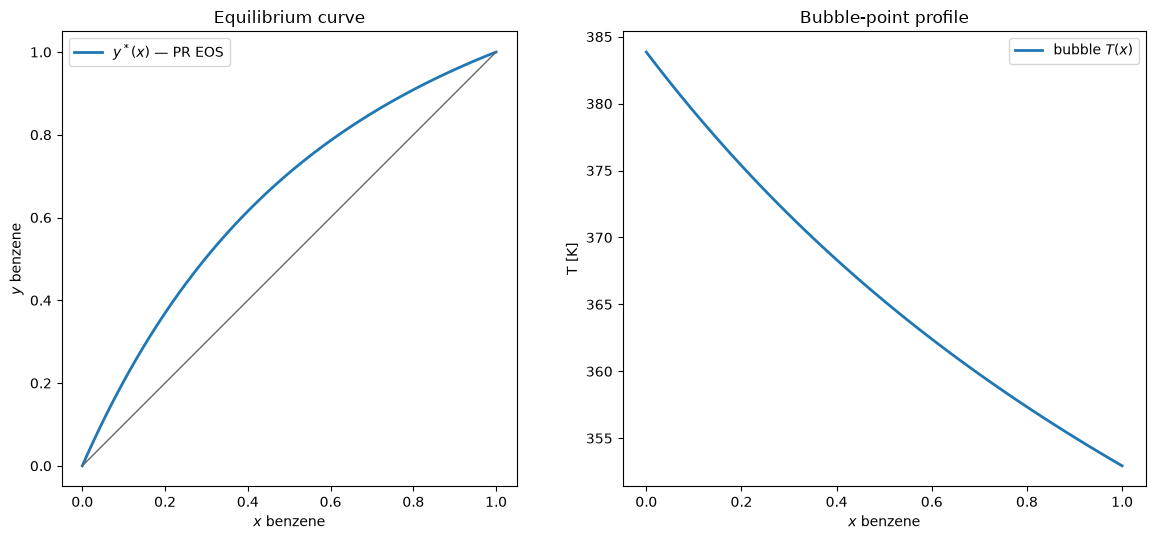

In [3]:
P = Q_(1, "atm").to("kPa").magnitude  # engine units: kPa absolute
bt = stages.ThermoSystem.peng_robinson(["benzene", "toluene"])  # light first
curve_bt = stages.EquilibriumCurve.from_thermo(bt, P, n_points=101)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
ax1.plot(curve_bt.x, curve_bt.y, lw=2, label="$y^*(x)$ — PR EOS")
ax1.plot([0, 1], [0, 1], color="0.4", lw=1)
ax1.set(xlabel="$x$ benzene", ylabel="$y$ benzene", title="Equilibrium curve", aspect="equal")
ax1.legend()
ax2.plot(curve_bt.x, curve_bt.t, lw=2, label="bubble $T(x)$")
ax2.set(xlabel="$x$ benzene", ylabel="T [K]", title="Bubble-point profile")
ax2.legend()
plt.tight_layout()

alpha_mid = curve_bt.relative_volatility(0.5)
print(f"T(x=0) = {curve_bt.t[0]:.2f} K (toluene bp 383.78 K)")
print(f"T(x=1) = {curve_bt.t[-1]:.2f} K (benzene bp 353.24 K)")
print(f"alpha(0.5) = {alpha_mid:.3f}")

The pinned assertions below make regressions fail loudly (repo validation rule):
$\alpha$ in the textbook window, endpoints at the pure boiling points.

In [4]:
assert abs(curve_bt.t[0] - 383.78) < 3.0, "toluene endpoint drifted"
assert abs(curve_bt.t[-1] - 353.24) < 3.0, "benzene endpoint drifted"
assert 2.30 < alpha_mid < 2.55, f"alpha(0.5) = {alpha_mid} left the textbook window"
print("equilibrium-curve pins OK")

equilibrium-curve pins OK


### Minimum reflux, then the design

`rmin` finds the pinch geometrically — it doesn't *assume* the pinch sits at the feed. For
this concave curve it lands there anyway (`tangent=False`), and the classic binary Underwood
closed form (S&H eq. 7-24, exact for constant $\alpha$, $q=1$) agrees using the curve's own
$\alpha$ at the pinch:

$$R_{\min} = \frac{1}{\alpha - 1}\left[\frac{x_D}{z_F} -
\alpha\,\frac{1 - x_D}{1 - z_F}\right]$$

In [5]:
xd, xb, zf, q = 0.95, 0.05, 0.50, 1.0
r = stages.rmin(curve_bt, xd, xb, zf, q=q)
alpha_pinch = curve_bt.relative_volatility(r.pinch[0])
underwood = (xd / zf - alpha_pinch * (1 - xd) / (1 - zf)) / (alpha_pinch - 1)
print(f"R_min = {r.r_min:.4f}   pinch at (x, y) = ({r.pinch[0]:.3f}, {r.pinch[1]:.3f})")
print(f"tangent pinch? {r.tangent}")
print(f"Underwood closed form with alpha(pinch) = {alpha_pinch:.3f}: {underwood:.4f}")

assert not r.tangent
assert abs(r.r_min - 1.163) < 0.02, f"R_min = {r.r_min} drifted from the pinned 1.163"
assert abs(r.r_min - underwood) / underwood < 0.05, "R_min disagrees with Underwood"
print("R_min pins OK")

R_min = 1.1628   pinch at (x, y) = (0.500, 0.708)
tangent pinch? False
Underwood closed form with alpha(pinch) = 2.425: 1.1628
R_min pins OK


R = 1.7442
N = 12.22 theoretical stages (incl. partial reboiler)
optimal feed stage = 6 (from the top)
N_min (total reflux) = 6.81


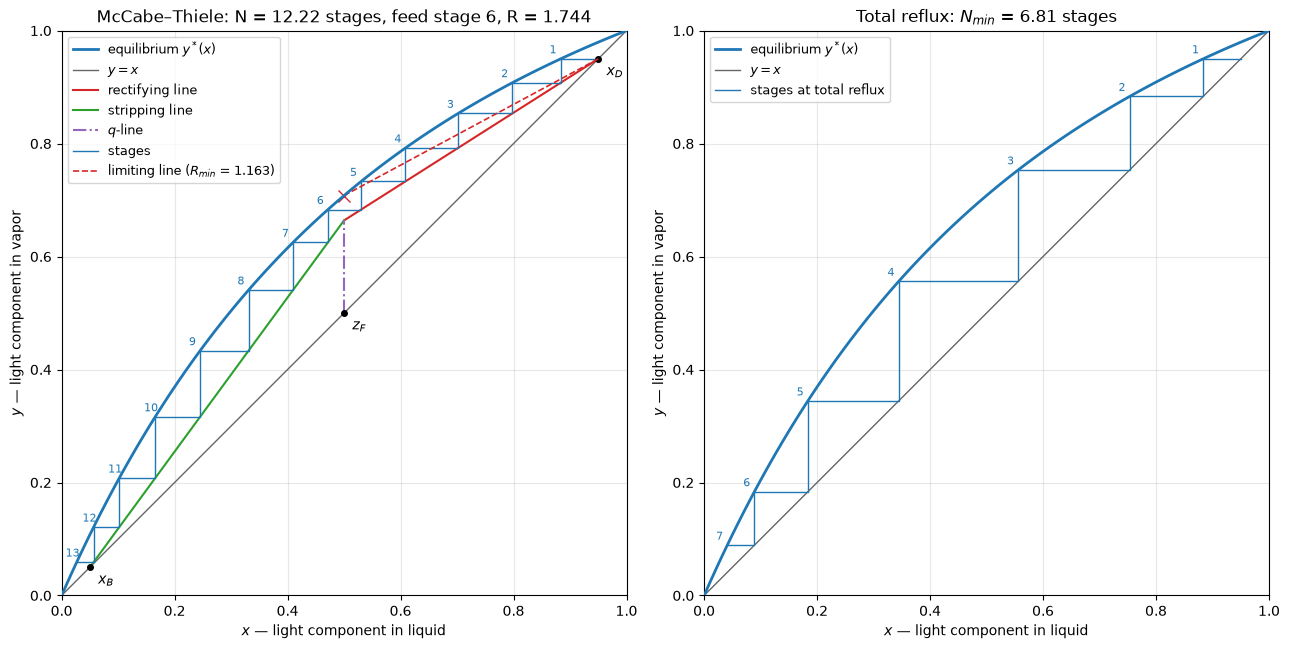

In [6]:
R = 1.5 * r.r_min
design = stages.mccabe_thiele(curve_bt, xd, xb, zf, reflux=R, q=q)
nmin = stages.total_reflux(curve_bt, xd, xb).n_min
print(f"R = {R:.4f}")
print(f"N = {design.n_stages:.2f} theoretical stages (incl. partial reboiler)")
print(f"optimal feed stage = {design.feed_stage} (from the top)")
print(f"N_min (total reflux) = {nmin:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.5))
plotting.plot_mccabe_thiele(design, curve_bt, ax=ax1, show_rmin=True)
plotting.plot_total_reflux(stages.total_reflux(curve_bt, xd, xb), curve_bt, ax=ax2)
plt.tight_layout()

Product rates come from the column model's material balances, and the whole design is
pinned:

In [7]:
col = stages.BinaryColumn(
    pressure=P,
    feed=stages.Feed(rate=100.0, z=zf, q=q),
    x_distillate=xd,
    x_bottoms=xb,
)
D, B = col.distillate_rate(), col.bottoms_rate()
print(f"D = {D:.2f} kmol/h, B = {B:.2f} kmol/h")

assert abs(D + B - 100.0) < 1e-9, "overall balance"
assert abs(D * xd + B * xb - 100.0 * zf) < 1e-9, "light-component balance"
assert abs(design.n_stages - 12.22) < 0.3, f"N = {design.n_stages} drifted from pinned 12.22"
assert design.feed_stage == 6, f"feed stage = {design.feed_stage}, pinned 6"
assert abs(nmin - 6.81) < 0.2, f"N_min = {nmin} drifted from pinned 6.81"
assert nmin < design.n_stages, "N at finite reflux must exceed N_min"
print("design pins OK")

D = 50.00 kmol/h, B = 50.00 kmol/h
design pins OK


### The design trade-off: N(R)

More reflux buys fewer stages (capital) at the cost of more boilup (energy). `n_vs_r` sweeps
the construction — NaN below $R_{\min}$, per the batch NaN-on-fail contract:

N(R) pins OK


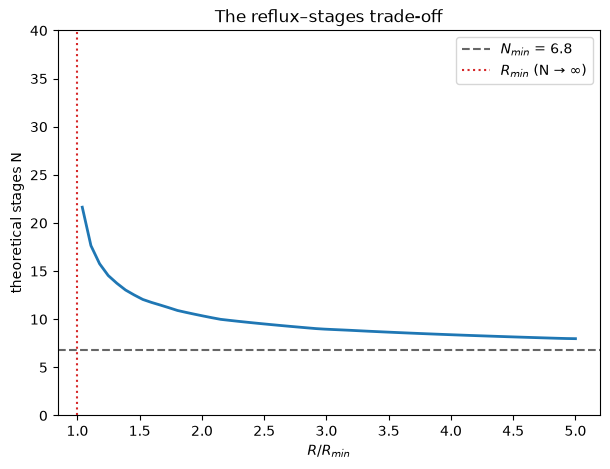

In [8]:
r_values = np.linspace(0.9 * r.r_min, 5.0 * r.r_min, 60)
pairs = stages.n_vs_r(curve_bt, list(r_values), xd, xb, zf, q=q)
rs = np.array([p[0] for p in pairs])
ns = np.array([p[1] for p in pairs])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rs / r.r_min, ns, lw=2)
ax.axhline(nmin, color="0.4", ls="--", label=f"$N_{{min}}$ = {nmin:.1f}")
ax.axvline(1.0, color="tab:red", ls=":", label="$R_{min}$ (N → ∞)")
ax.set(xlabel="$R / R_{min}$", ylabel="theoretical stages N",
       title="The reflux–stages trade-off", ylim=(0, 40))
ax.legend()

assert np.isnan(ns[rs < r.r_min]).all(), "below R_min must be NaN"
finite = ns[~np.isnan(ns)]
assert (np.diff(finite) <= 1e-9).all(), "N(R) must be non-increasing"
print("N(R) pins OK")

## Worked example 2 — methanol–water (van Laar, γ-φ): tying back to vle Chapter IV

The thermodynamics here is *exactly* the system validated in vle's Chapter IV notebooks:
methanol(1)–water(2) with van Laar parameters $\Lambda_{12} = 0.5853$, $\Lambda_{21} =
0.3458$ (Orbey & Sandler, Table 4.5), ideal vapor. Before designing a column on it, we
reproduce a row of the thesis's **Table 4.6** (bubble pressure at 298 K) through the
`stages` adapter — same numbers, new route:

In [9]:
mw = stages.ThermoSystem.van_laar(["methanol", "water"], 0.5853, 0.3458)

# Table 4.6, row x1 = 0.4943: thesis reports y1 = 0.8334, P = 10.9757 kPa.
p_bub, y_bub, _ = mw.bubble_pressure(298.15, [0.4943, 1 - 0.4943])
print(f"stages:  P = {p_bub:.4f} kPa, y1 = {y_bub[0]:.4f}")
print("thesis:  P = 10.9757 kPa, y1 = 0.8334   (Table 4.6)")

assert abs(y_bub[0] - 0.8334) < 0.01, "y1 must match Table 4.6 tightly"
assert abs(p_bub - 10.9757) / 10.9757 < 0.025, "P within the Psat-correlation band"
print("Chapter IV tie-in OK")

stages:  P = 10.9369 kPa, y1 = 0.8319
thesis:  P = 10.9757 kPa, y1 = 0.8334   (Table 4.6)
Chapter IV tie-in OK


Now the 1 atm column. Methanol–water is strongly non-ideal (positive deviation,
$\gamma_1^\infty = e^{0.5853} \approx 1.8$) but azeotrope-free — the curve bulges high above
the diagonal at low methanol, which is why a modest reflux ratio distills it:

R_min = 0.6841 (pinch at x = 0.400, tangent: False)
N = 8.35, feed stage 5
methanol–water pins OK


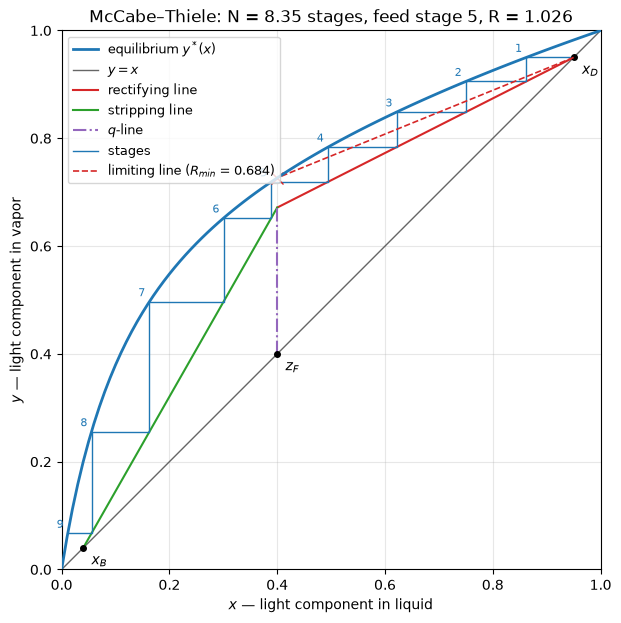

In [10]:
curve_mw = stages.EquilibriumCurve.from_thermo(mw, P, n_points=101)
xd, xb, zf = 0.95, 0.04, 0.40
r_mw = stages.rmin(curve_mw, xd, xb, zf, q=1.0)
design_mw = stages.mccabe_thiele(curve_mw, xd, xb, zf, reflux=1.5 * r_mw.r_min, q=1.0)
print(f"R_min = {r_mw.r_min:.4f} (pinch at x = {r_mw.pinch[0]:.3f}, tangent: {r_mw.tangent})")
print(f"N = {design_mw.n_stages:.2f}, feed stage {design_mw.feed_stage}")

ax = plotting.plot_mccabe_thiele(design_mw, curve_mw, show_rmin=True)

assert all(curve_mw.y_of_x(x) > x for x in (0.05, 0.3, 0.6, 0.9)), "no azeotrope expected"
assert abs(curve_mw.t[0] - 373.12) < 2.0 and abs(curve_mw.t[-1] - 337.7) < 2.0
assert abs(r_mw.r_min - 0.684) < 0.02, f"R_min = {r_mw.r_min} drifted from pinned 0.684"
assert abs(design_mw.n_stages - 8.35) < 0.3, f"N = {design_mw.n_stages} drifted from 8.35"
print("methanol–water pins OK")

Note what just happened across the two examples: the *same* construction code ran on
a cubic-EOS curve and an activity-model curve — the McCabe–Thiele layer never knows which
thermodynamics produced $y^*(x)$. That separation (solvers ↔ thermo adapter) is the
load-bearing design rule of the whole library (PLAN §7).

## Exercises

### Exercise 1 — ethanol–water: azeotropes and the tangent pinch

Ethanol(1)–water(2) at 1 atm forms a minimum-boiling azeotrope near $x_1 \approx 0.89$.
Build the system with van Laar parameters $A_{12} = 1.6798$, $A_{21} = 0.9227$ (Perry's
classic set) and:

1. Generate the equilibrium curve (use `n_points=201`) and locate the azeotrope (where
   $y^* = x$).
2. Try to design for $x_D = 0.95$, $x_B = 0.05$, $z_F = 0.30$, $q = 1$. What happens, and
   why?
3. Redesign for $x_D = 0.85$. Inspect `rmin(...)` — where is the pinch, and is it the feed
   point? Plot the construction at $R = 1.5\,R_{\min}$ with `show_rmin=True` and look at
   where the limiting line touches the curve.

In [11]:
# TODO: build the ethanol–water ThermoSystem (van_laar, A12=1.6798, A21=0.9227)
# TODO: find the azeotrope from curve.x / curve.y
# TODO: attempt x_D = 0.95 (catch the exception), then design for x_D = 0.85
# TODO: plot with show_rmin=True and inspect rmin(...).tangent / .pinch


<details>
<summary><b>Solution — exercise 1</b> (click to expand)</summary>

```python
ew = stages.ThermoSystem.van_laar(["ethanol", "water"], 1.6798, 0.9227)
curve_ew = stages.EquilibriumCurve.from_thermo(ew, P, n_points=201)

# 1. Azeotrope: y* - x changes sign near x = 0.91 (literature: 0.894 —
#    van Laar with ideal vapor lands close).
diff = np.array(curve_ew.y) - np.array(curve_ew.x)
i = np.where(np.diff(np.sign(diff[1:-1])))[0][0] + 1
print(f"azeotrope near x = {curve_ew.x[i]:.3f}")

# 2. x_D = 0.95 sits ABOVE the azeotrope — no operating line can reach it:
try:
    stages.rmin(curve_ew, 0.95, 0.05, 0.30, q=1.0)
except ValueError as e:
    print(f"infeasible, as expected: {e}")

# 3. x_D = 0.85 works, but the controlling pinch is TANGENT — the curve
#    flattens toward the azeotrope and touches the operating line at
#    x ≈ 0.74, far from the feed:
r_ew = stages.rmin(curve_ew, 0.85, 0.05, 0.30, q=1.0)
print(f"R_min = {r_ew.r_min:.3f}, tangent = {r_ew.tangent}, pinch x = {r_ew.pinch[0]:.3f}")
res_ew = stages.mccabe_thiele(curve_ew, 0.85, 0.05, 0.30, reflux=1.5 * r_ew.r_min)
plotting.plot_mccabe_thiele(res_ew, curve_ew, show_rmin=True)
print(f"N = {res_ew.n_stages:.1f}, feed stage {res_ew.feed_stage}")
# R_min ≈ 1.70 with the pinch at x ≈ 0.735 — a feed-point analysis would
# have underestimated the reflux the column actually needs.
```
</details>

### Exercise 2 — feed quality: why q matters

Repeat the benzene–toluene design (worked example 1) with a **saturated-vapor** feed
($q = 0$) instead of saturated liquid, at $R = 1.5\,R_{\min}(q{=}0)$.

1. How much does $R_{\min}$ increase, and why (think about which section must do the work
   when the feed arrives as vapor)?
2. Compare the two staircases side by side. Which direction did the q-line rotate, and
   where did the optimal feed stage move?

In [12]:
# TODO: rmin and mccabe_thiele for q=0 on curve_bt; compare with the q=1 design
# TODO: two-panel plot of both constructions


<details>
<summary><b>Solution — exercise 2</b> (click to expand)</summary>

```python
r_q0 = stages.rmin(curve_bt, 0.95, 0.05, 0.50, q=0.0)
res_q0 = stages.mccabe_thiele(curve_bt, 0.95, 0.05, 0.50,
                              reflux=1.5 * r_q0.r_min, q=0.0)
print(f"q=1: R_min = {r.r_min:.3f}   q=0: R_min = {r_q0.r_min:.3f}")
print(f"q=0 design: N = {res_q0.n_stages:.2f}, feed stage {res_q0.feed_stage}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.5))
plotting.plot_mccabe_thiele(design, curve_bt, ax=ax1)
plotting.plot_mccabe_thiele(res_q0, curve_bt, ax=ax2)
plt.tight_layout()

# R_min roughly doubles (≈ 1.16 → ≈ 2.21): a vapor feed carries no liquid
# into the stripping section, so the condenser must generate ALL the liquid
# the column needs — the q-line is horizontal (rotated clockwise from
# vertical), the operating-line intersection slides left along y = z_F, and
# the pinch composition moves to y* = z_F. The feed stage moves up in
# composition terms but the rectifying section shortens.
```
</details>

### Exercise 3 — real trays: Murphree efficiency

Real trays don't reach equilibrium. Re-run the benzene–toluene design with a Murphree vapor
efficiency $E_{MV} = 0.75$ (`murphree=0.75`) and compare the stage count against the ideal
construction and against the naive estimate $N/E_{MV}$. Why is the naive estimate not
exact?

In [13]:
# TODO: mccabe_thiele(..., murphree=0.75) and compare n_stages


<details>
<summary><b>Solution — exercise 3</b> (click to expand)</summary>

```python
res_e = stages.mccabe_thiele(curve_bt, 0.95, 0.05, 0.50,
                             reflux=R, q=1.0, murphree=0.75)
print(f"ideal N = {design.n_stages:.2f}")
print(f"E_MV = 0.75: N = {res_e.n_stages:.2f}")
print(f"naive N / E = {design.n_stages / 0.75:.2f}")
# ≈ 16.3 actual vs ≈ 16.3 naive here — close for this near-ideal system, but
# not exact in general: the pseudo-curve compresses each step by 25% *of the
# local gap to the operating line*, which varies along the column (largest
# near the feed, smallest near the pinched ends), while N/E scales every
# stage uniformly.
```
</details>

## References

- McCabe, W. L.; Thiele, E. W. Graphical Design of Fractionating Columns. *Ind. Eng.
  Chem.* **1925**, 17 (6), 605–611.
- Seader, J. D.; Henley, E. J.; Roper, D. K. *Separation Process Principles*, Ch. 7 —
  the implementation-level source for every equation here (7-9, 7-12, 7-24, 7-26).
- Orbey, H.; Sandler, S. I. — the van Laar parameter set behind the Chapter IV
  methanol–water validation (vle repo, Tables 4.5/4.6).
- Theory as implemented: [`docs/theory/mccabe-thiele.md`](../docs/theory/mccabe-thiele.md);
  full citation list: [`docs/references.md`](../docs/references.md); algorithm rationale:
  `PLAN.md` §4–§5.
- Next rung of the ladder: `02-ponchon-savarit.ipynb` (M2) drops the constant-molal-overflow
  assumption by putting enthalpy on the diagram.